# Multiserver jobs: why you can't use all of your cluster

In classic queueing one job uses one server. But in a cloud or GPU cluster a single job often needs
**several servers at once** for its whole run: a training job asks for 4 GPUs, an inference job for
1. This is the **multiserver-job (MSJ)** model.

The non-obvious lesson for an engineer: because of *packing* and head-of-line *blocking*, a cluster
of `k` servers with mean rate `μ` **cannot sustain `k·μ` jobs/second**. A mix of "narrow" and "wide"
jobs quietly throws away 20–30% of capacity, and response time blows up far below the naive limit.

We use the library's exact MSJ tools plus its simulator.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from most_queue.theory.msj import MsjClass, MsjExactCalc, MsjSaturatedCalc
from most_queue.sim.msj import MsjSim

plt.rcParams.update({"figure.figsize": (8, 5), "axes.grid": True, "font.size": 11})
K, MU = 4, 1.0                 # 4-GPU cluster
NEED_SMALL, NEED_WIDE = 1, 4   # a 1-GPU job and a 4-GPU job

def classes_mix(wide_frac, lam_total=1.0):
    # jobs are 'wide' (need all 4 GPUs) with probability wide_frac, else 'narrow' (1 GPU)
    cl = []
    if wide_frac < 1.0:
        cl.append(MsjClass(lam_total * (1 - wide_frac), NEED_SMALL, MU))
    if wide_frac > 0.0:
        cl.append(MsjClass(lam_total * wide_frac, NEED_WIDE, MU))
    return cl


## 1. The capacity you can't use

`MsjSaturatedCalc` gives `X_sat`, the exact **maximum sustainable arrival rate** (the stability
threshold). Compare it to the *ideal packing* bound `k / E[need] · μ` — what you could do if work
packed perfectly.

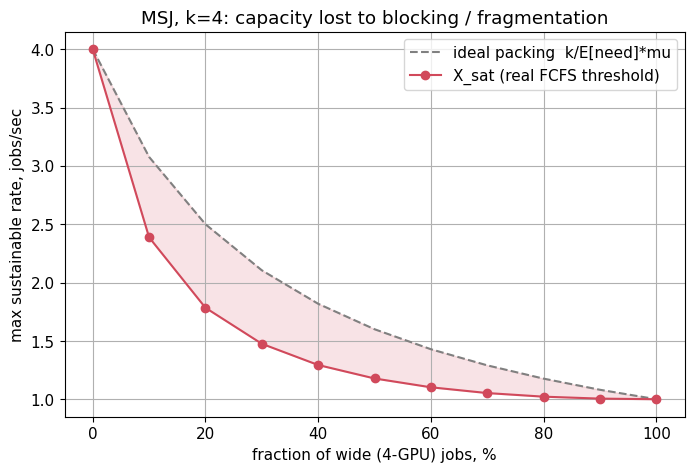

   10% wide: X_sat=2.388  ideal=3.077  -> 22% lost

   20% wide: X_sat=1.784  ideal=2.500  -> 29% lost

   30% wide: X_sat=1.475  ideal=2.105  -> 30% lost

   40% wide: X_sat=1.293  ideal=1.818  -> 29% lost

   50% wide: X_sat=1.178  ideal=1.600  -> 26% lost

   60% wide: X_sat=1.102  ideal=1.429  -> 23% lost

   70% wide: X_sat=1.053  ideal=1.290  -> 18% lost

   80% wide: X_sat=1.022  ideal=1.176  -> 13% lost

   90% wide: X_sat=1.005  ideal=1.081  -> 7% lost

In [2]:
wfs = np.linspace(0, 1, 11)
x_sat = [MsjSaturatedCalc(k=K, classes=classes_mix(w)).run() for w in wfs]
ideal = [K / ((1 - w) * NEED_SMALL + w * NEED_WIDE) * MU for w in wfs]

fig, ax = plt.subplots()
ax.plot(wfs * 100, ideal, "--", color="gray", label="ideal packing  k/E[need]*mu")
ax.plot(wfs * 100, x_sat, "o-", color="#d1495b", label="X_sat (real FCFS threshold)")
ax.fill_between(wfs * 100, x_sat, ideal, alpha=0.15, color="#d1495b")
ax.set_xlabel("fraction of wide (4-GPU) jobs, %")
ax.set_ylabel("max sustainable rate, jobs/sec")
ax.set_title(f"MSJ, k={K}: capacity lost to blocking / fragmentation")
ax.legend()
plt.show()

for w, xs, idl in zip(wfs, x_sat, ideal):
    if 0 < w < 1:
        print(f"  {w*100:3.0f}% wide: X_sat={xs:.3f}  ideal={idl:.3f}  -> {(1-xs/idl)*100:.0f}% lost")


**The insight.** Even a 10–25% share of wide jobs drops the real throughput **20–30% below**
the ideal-packing bound. A wide job at the head of the FCFS queue holds all 4 GPUs and blocks narrow
jobs behind it — even while 3 GPUs sit idle. This capacity loss is invisible in an M/M/c model.

## 2. Response time explodes long before `k·μ`

Fix a mix of **70% narrow / 30% wide**. Naively a 4-GPU cluster should handle almost `k·μ = 4`. In
reality the threshold `X_sat` is much lower, and mean response time diverges there. We draw the curve
by simulation and validate it with the exact calculator at low-to-moderate load.

X_sat for the 70/30 mix = 1.475   (naive k*mu = 4)

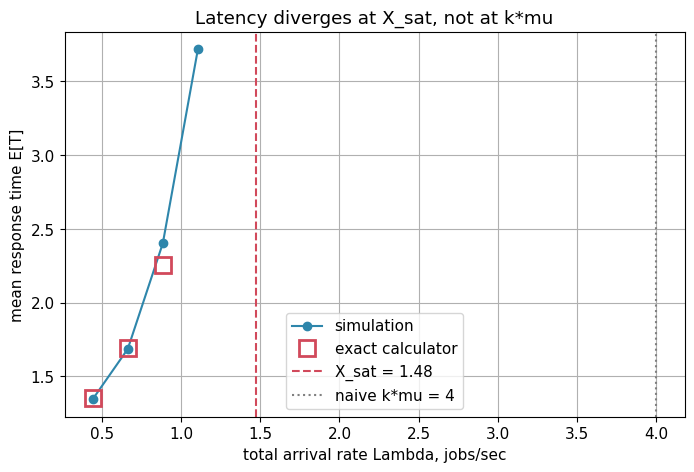

In [3]:
wf = 0.3
x_sat_mix = MsjSaturatedCalc(k=K, classes=classes_mix(wf)).run()
print(f"X_sat for the 70/30 mix = {x_sat_mix:.3f}   (naive k*mu = {K*MU:.0f})")

def make_classes(lam):
    return [MsjClass(lam * (1 - wf), NEED_SMALL, MU), MsjClass(lam * wf, NEED_WIDE, MU)]

sim_lam, sim_et = [], []
for fr in [0.3, 0.45, 0.6, 0.75]:
    lam = fr * x_sat_mix
    sim_et.append(MsjSim(k=K, classes=make_classes(lam), seed=7).run(30_000).v[0])
    sim_lam.append(lam)

ex_lam, ex_et = [], []
for fr in [0.3, 0.45, 0.6]:
    lam = fr * x_sat_mix
    c = MsjExactCalc(k=K, classes=make_classes(lam), truncation=13)
    r = c.run()
    if c.boundary_mass < 1e-2:
        ex_lam.append(lam); ex_et.append(r.v[0])

fig, ax = plt.subplots()
ax.plot(sim_lam, sim_et, "o-", color="#2e86ab", label="simulation")
ax.plot(ex_lam, ex_et, "s", ms=11, mfc="none", mec="#d1495b", mew=2, label="exact calculator")
ax.axvline(x_sat_mix, ls="--", color="#d1495b", label=f"X_sat = {x_sat_mix:.2f}")
ax.axvline(K * MU, ls=":", color="gray", label=f"naive k*mu = {K*MU:.0f}")
ax.set_xlabel("total arrival rate Lambda, jobs/sec")
ax.set_ylabel("mean response time E[T]")
ax.set_title("Latency diverges at X_sat, not at k*mu")
ax.legend()
plt.show()


**The insight.** The usable capacity of this cluster is `X_sat ≈ 1.5`, **three times lower**
than the naive `k·μ = 4`. Plan load against `X_sat`. The exact calculator (red squares) matches the
simulation where the state-space truncation is still accurate; beyond `X_sat` the system is unstable
and the queue grows without bound.

## Takeaways for engineers

- MSJ ≠ M/M/c: a job holding several servers changes everything. You **cannot** use `k·μ` — packing
  and FCFS blocking cost 20–30% of it. Size clusters against `X_sat` (`MsjSaturatedCalc`).
- Wide jobs block narrow ones even when servers are free; smarter policies (backfilling /
  ServerFilling) recover some of this — a direction for future work.
- The multiserver-job model is the first-class way to reason about GPU/core reservations, and no
  other open-source package provides it. See the [MSJ models](../docs/models.md).